In [1]:
import nltk
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from utils import stop_words, lemmatizer, clean_data

[nltk_data] Downloading package stopwords to /home/janusz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/janusz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# Load dataset
df = pd.read_csv('yelp_labelled.csv', sep='\t')

In [3]:
df.head()

,review,status
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


<Axes: xlabel='status', ylabel='count'>

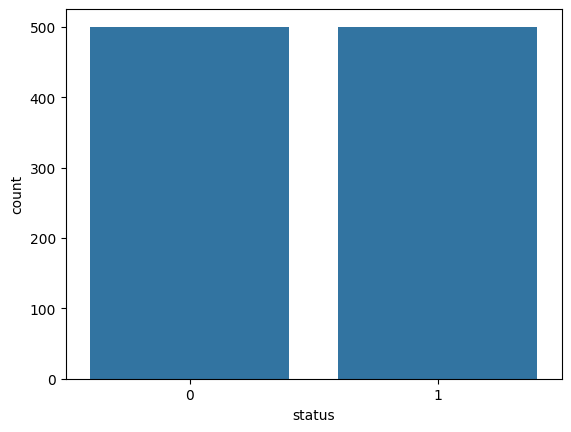

In [4]:
# Check if te data is balanced
sns.countplot(data=df, x='status')

In [5]:
# Apply preprocessing to the review column
df.review = df.review.apply(clean_data)

In [6]:
df.head()

,review,status
0,wow loved place,1
1,crust good,0
2,tasty texture nasty,0
3,stopped late may bank holiday rick steve recom...,1
4,selection menu great price,1


In [7]:
# Split data into training and testing sets (67% train, 33% test)
X_train, X_test, y_train, y_test = train_test_split(df.review, df.status, test_size=0.33, random_state=42)

In [8]:
# Define a Pipeline that combines TF-IDF Vectorization and Logistic Regression
# ngram_range=(1, 2) includes both single words and pairs of words
pipe = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), min_df=2)), 
    ('model', LogisticRegression())])

In [9]:
# Train the model
pipe.fit(X_train, y_train)

,steps,"[('vectorizer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [10]:
# Evaluate model performance using Accuracy
pipe.score(X_test,  y_test)

0.7606060606060606

In [11]:
# Perform 5-fold Cross-Validation to ensure model stability
scores = cross_val_score(estimator=pipe, X=X_train, y=y_train)

In [12]:
scores

array([0.79104478, 0.8358209 , 0.75373134, 0.71641791, 0.75373134])

In [13]:
scores.mean()

np.float64(0.7701492537313432)

In [14]:
scores.std()

np.float64(0.040436469206400205)

In [15]:
# Generate predictions for evaluation
predictions = pipe.predict(X_test)

In [16]:
# Extracting words (features) and their corresponding coefficients from the model
feature_names = pipe.named_steps['vectorizer'].get_feature_names_out()
importances = pipe.named_steps['model'].coef_.flatten()
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)

In [17]:
importances = pipe.named_steps['model'].coef_.flatten()

In [18]:
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)

In [19]:
# Get top 10 positive and negative words influencing the model
pos_imortances = importances_df.head(10)
neg_imortances = importances_df.tail(10)

In [20]:
neg_imortances = importances_df.tail(10)

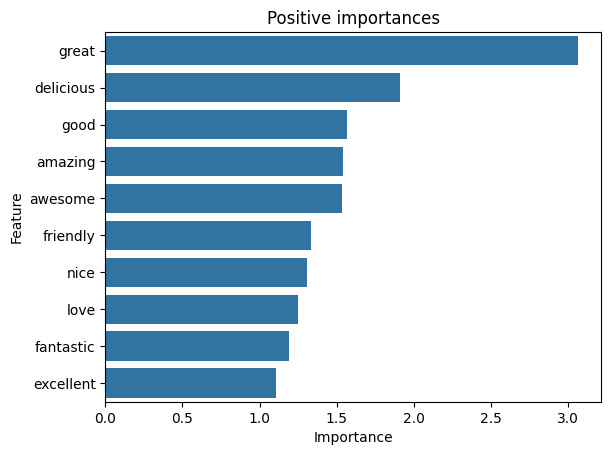

In [21]:
# Visualize Positive Importances
plt.figure()
g = sns.barplot(data=pos_imortances, x='Importance', y='Feature')
g.set_title('Positive importances')
plt.show()

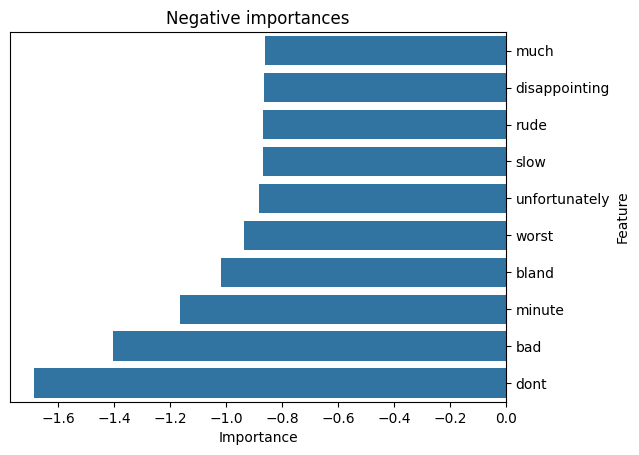

In [22]:
# Visualize Negative Importances
plt.figure()
n = sns.barplot(data=neg_imortances, x='Importance', y='Feature')
n.set_title('Negative importances')
n.yaxis.tick_right()
n.yaxis.set_label_position("right")
plt.show()

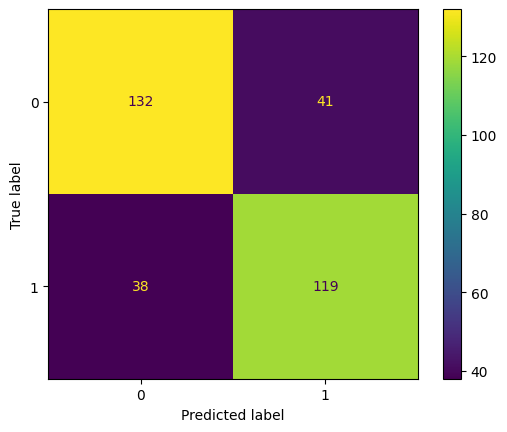

In [23]:
# Display Confusion Matrix
cm = confusion_matrix(y_test, predictions, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipe.classes_)
disp.plot()

In [24]:
# Detailed classification report (Precision, Recall, F1-score)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       173
           1       0.74      0.76      0.75       157

    accuracy                           0.76       330
   macro avg       0.76      0.76      0.76       330
weighted avg       0.76      0.76      0.76       330



In [25]:
# Export the entire pipeline for deployment
joblib.dump(pipe, 'classifier.pkl')

['classifier.pkl']